# Part 1 – Network Architecture (MLP Baseline)

## Step 1: Load Dataset

In this step, we load the Cars Dataset into memory using pandas.
This dataset contains both numerical and categorical features related to car specifications,
and the target variable is the car price.

The purpose of this step is only to load the raw data and verify that it was imported correctly.
No preprocessing is applied yet.


In [1]:
import pandas as pd
import numpy as np

def load_dataset(path: str) -> pd.DataFrame:
    """
    Loads the car dataset from a CSV file.

    Parameters
    ----------
    path : str
        Path to the CSV file.

    Returns
    -------
    pd.DataFrame
        Loaded dataset as a pandas DataFrame.
    """
    df = pd.read_csv(path)
    return df


# Load dataset
df = load_dataset("CarsDatasets.csv")

# Display first rows
df.head()


,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
0,FERRARI,SF90 STRADALE,V8,3990 cc,963 hp,340 km/h,2.5 sec,"$1,100,000",plug in hyrbrid,2,800 Nm
1,ROLLS ROYCE,PHANTOM,V12,6749 cc,563 hp,250 km/h,5.3 sec,"$460,000",Petrol,5,900 Nm
2,Ford,KA+,1.2L Petrol,"1,200 cc",70-85 hp,165 km/h,10.5 sec,"$12,000-$15,000",Petrol,5,100 - 140 Nm
3,MERCEDES,GT 63 S,V8,"3,982 cc",630 hp,250 km/h,3.2 sec,"$161,000",Petrol,4,900 Nm
4,AUDI,AUDI R8 Gt,V10,"5,204 cc",602 hp,320 km/h,3.6 sec,"$253,290",Petrol,2,560 Nm


## Step 2: Inspect Dataset Structure

In this step, we inspect:
- Number of samples and features
- Data types of each column
- Presence of missing values

This allows us to understand what kind of preprocessing is required,
especially for numerical features stored as strings and categorical variables.


In [2]:
def inspect_dataset(df: pd.DataFrame):
    """
    Prints basic structural information about the dataset.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataset.
    """
    print("Shape:", df.shape)
    print("\nColumn types:\n")
    print(df.dtypes)
    print("\nMissing values per column:\n")
    print(df.isnull().sum())


inspect_dataset(df)


Shape: (1218, 11)

Column types:

Company Names                object
Cars Names                   object
Engines                      object
CC/Battery Capacity          object
HorsePower                   object
Total Speed                  object
Performance(0 - 100 )KM/H    object
Cars Prices                  object
Fuel Types                   object
Seats                         int64
Torque                       object
dtype: object

Missing values per column:

Company Names                0
Cars Names                   0
Engines                      0
CC/Battery Capacity          3
HorsePower                   0
Total Speed                  0
Performance(0 - 100 )KM/H    6
Cars Prices                  0
Fuel Types                   0
Seats                        0
Torque                       1
dtype: int64


## Step 3: Separate Target and Features

The target variable in this problem is `Cars Prices`.
All other columns are considered input features.

We separate them now so that future preprocessing steps
do not accidentally modify the target.


In [3]:
def split_features_target(df: pd.DataFrame, target_col: str):
    """
    Splits dataset into features X and target y.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataset.
    target_col : str
        Name of target column.

    Returns
    -------
    X : pd.DataFrame
        Feature matrix.
    y : pd.Series
        Target vector.
    """
    X = df.drop(columns=[target_col])
    y = df[target_col]
    return X, y


X_raw, y_raw = split_features_target(df, "Cars Prices")

print(X_raw.shape, y_raw.shape)


(1218, 10) (1218,)


## Step 4: Identify Feature Types

The dataset contains a mixture of:
- Categorical features (brand, fuel type, engine type)
- Numerical features stored as strings (horsepower, speed, torque, etc.)

We explicitly separate them because:
- Categorical features will require encoding
- Numerical features will require parsing and normalization


In [4]:
def identify_feature_types(X: pd.DataFrame):
    """
    Identifies categorical and numerical columns based on data type.

    Parameters
    ----------
    X : pd.DataFrame
        Feature matrix.

    Returns
    -------
    categorical_cols : list
        List of categorical column names.
    numerical_cols : list
        List of numerical column names.
    """
    categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
    numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()
    return categorical_cols, numerical_cols


categorical_cols, numerical_cols = identify_feature_types(X_raw)

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)


Categorical: ['Company Names', 'Cars Names', 'Engines', 'CC/Battery Capacity', 'HorsePower', 'Total Speed', 'Performance(0 - 100 )KM/H', 'Fuel Types', 'Torque']
Numerical: ['Seats']


## Step 5: Train / Validation / Test Split

The dataset is split into:
- 70% training
- 15% validation
- 15% test

This ensures:
- Training data for learning
- Validation data for model selection
- Test data for final unbiased evaluation

A fixed random seed is used to ensure reproducibility.


In [5]:
from sklearn.model_selection import train_test_split

def split_data(X, y, train_ratio=0.7, val_ratio=0.15, random_state=42):
    """
    Splits data into train, validation, and test sets.

    Parameters
    ----------
    X : array-like
        Feature matrix.
    y : array-like
        Target vector.
    train_ratio : float
        Proportion of training data.
    val_ratio : float
        Proportion of validation data.
    random_state : int
        Random seed.

    Returns
    -------
    X_train, X_val, X_test, y_train, y_val, y_test
    """
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=(1 - train_ratio), random_state=random_state
    )

    val_size = val_ratio / (1 - train_ratio)

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=(1 - val_size), random_state=random_state
    )

    return X_train, X_val, X_test, y_train, y_val, y_test


X_train_raw, X_val_raw, X_test_raw, y_train, y_val, y_test = split_data(X_raw, y_raw)

print("Train:", X_train_raw.shape)
print("Val:", X_val_raw.shape)
print("Test:", X_test_raw.shape)


Train: (852, 10)
Val: (182, 10)
Test: (184, 10)


## Step 6: Define MLP Architecture

We define a Multilayer Perceptron with the following structure:

- Input layer: size = number of input features
- Hidden layer 1: 64 neurons, ReLU activation
- Hidden layer 2: 32 neurons, ReLU activation
- Output layer: 1 neuron, Linear activation

This architecture will remain fixed for all experiments in Question 1.
Only preprocessing, training strategies, and optimizers will change.


In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_mlp(input_dim: int) -> tf.keras.Model:
    """
    Builds a baseline MLP model for regression.

    Parameters
    ----------
    input_dim : int
        Number of input features.

    Returns
    -------
    model : tf.keras.Model
        Compiled MLP model.
    """
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="linear")
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=[tf.keras.metrics.RootMeanSquaredError()]
    )

    return model


# Example (will work after encoding)
# model = build_mlp(input_dim=NUM_FEATURES)
# model.summary()


# Part 2 – Categorical Feature Encoding
Conceptual Goal (important to understand first)
You are testing this hypothesis:

The way we represent categorical variables changes the geometry of the input space, and therefore changes how the neural network learns.

You will compare three worlds:
1. One-Hot Encoding
2. Target Encoding
3. Embedding Layer

Everything else must remain identical.

## Step 1: Identify Categorical Features

In this step, we explicitly identify categorical features that require encoding.
These features cannot be directly used by neural networks and must be converted
to numerical representations.

We will apply three different encoding strategies to these features and compare
their effect on model learning.


In [7]:
categorical_cols, numerical_cols = identify_feature_types(X_train_raw)

categorical_cols, numerical_cols


(['Company Names',
  'Cars Names',
  'Engines',
  'CC/Battery Capacity',
  'HorsePower',
  'Total Speed',
  'Performance(0 - 100 )KM/H',
  'Fuel Types',
  'Torque'],
 ['Seats'])

## Step 2: One-Hot Encoding

One-Hot Encoding represents each category as a binary vector.
For example, a feature with 4 categories becomes 4 new binary columns.

Advantages:
- Simple and interpretable
- No information leakage

Disadvantages:
- High dimensionality
- No notion of similarity between categories


In [8]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

def one_hot_preprocess(X_train, X_val, X_test, categorical_cols, numerical_cols):
    """
    Applies One-Hot Encoding to categorical features and standardization to numerical features.

    Returns processed train, validation, and test sets.
    """
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numerical_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
        ]
    )

    X_train_enc = preprocessor.fit_transform(X_train)
    X_val_enc   = preprocessor.transform(X_val)
    X_test_enc  = preprocessor.transform(X_test)

    return X_train_enc, X_val_enc, X_test_enc, preprocessor


X_train_oh, X_val_oh, X_test_oh, oh_preprocessor = one_hot_preprocess(
    X_train_raw, X_val_raw, X_test_raw,
    categorical_cols, numerical_cols
)

X_train_oh.shape


(852, 2305)

## Step 3: Target Encoding

Target Encoding replaces each category with the mean value of the target variable
for that category.

Example:
If "BMW" cars have average price = 70,000,
then all BMW entries become 70,000.

Advantages:
- Low dimensional
- Injects semantic information

Disadvantages:
- Risk of data leakage
- Can cause overfitting if not careful


The target column `Cars Prices` contains heterogeneous string formats:
- Currency values (e.g. "$1,200,000")
- Plain numbers (e.g. "35000")
- Ranges (e.g. "12000-15000")

Since machine learning models require a single numeric value,
we convert all formats into a single float representation.

For price ranges, we use the midpoint of the interval.


In [9]:
import re
import numpy as np
import pandas as pd

def parse_price_column(y: pd.Series) -> pd.Series:
    """
    Converts heterogeneous price strings into numeric floats.

    Handles:
    - "$1,200,000"        -> 1200000
    - "12000-15000"      -> 13500
    - "55000 / 65000"    -> 60000
    - "35000"            -> 35000
    - Any mixed format   -> mean of all numbers found
    """

    def parse_single_value(val):
        if pd.isna(val):
            return np.nan

        val = str(val)

        # Extract all numbers from the string
        numbers = re.findall(r"\d+\.?\d*", val.replace(",", ""))

        if len(numbers) == 0:
            return np.nan

        numbers = [float(n) for n in numbers]

        # If multiple numbers exist, take their mean
        return np.mean(numbers)

    return y.apply(parse_single_value)


# 1. Parse target
y_raw = parse_price_column(df["Cars Prices"])
X_raw = df.drop(columns=["Cars Prices"])

# Sanity check
print(y_raw.describe())
print(y_raw.isna().sum())


count    1.217000e+03
mean     1.380370e+05
std      7.110424e+05
min      4.000000e+03
25%      2.800000e+04
50%      4.250000e+04
75%      7.000000e+04
max      1.800000e+07
Name: Cars Prices, dtype: float64
1


## Step 4: Embedding Layer Encoding

Embedding layers learn a dense vector representation for each category.
Instead of manually defining relationships, the network learns them
during training.

Advantages:
- Learns similarity between categories
- Compact representation
- Scales well to high cardinality

Disadvantages:
- Less interpretable
- Requires more careful model design


In [10]:
from sklearn.preprocessing import LabelEncoder

def label_encode_features(X_train, X_val, X_test, categorical_cols):
    """
    Converts categorical features into integer indices for embedding layers.
    """
    X_train_le = X_train.copy()
    X_val_le   = X_val.copy()
    X_test_le  = X_test.copy()

    encoders = {}

    for col in categorical_cols:
        le = LabelEncoder()
        X_train_le[col] = le.fit_transform(X_train[col])
        X_val_le[col]   = le.transform(X_val[col])
        X_test_le[col]  = le.transform(X_test[col])
        encoders[col] = le

    return X_train_le, X_val_le, X_test_le, encoders


## Step 5: MLP with Embedding Layers

In this model, each categorical feature has its own embedding layer.
Numerical features are concatenated directly.
All representations are merged and passed to dense layers.


In [11]:
def build_mlp_with_embeddings(cat_dims, num_dim, emb_dim=8):
    """
    Builds an MLP model with embedding layers for categorical features.

    Parameters
    ----------
    cat_dims : dict
        Dictionary of {feature_name: number_of_unique_values}
    num_dim : int
        Number of numerical features
    emb_dim : int
        Size of embedding vectors

    Returns
    -------
    model : tf.keras.Model
    """
    inputs = []
    embeddings = []

    for name, dim in cat_dims.items():
        inp = layers.Input(shape=(1,), name=name)
        emb = layers.Embedding(input_dim=dim, output_dim=emb_dim)(inp)
        emb = layers.Flatten()(emb)
        inputs.append(inp)
        embeddings.append(emb)

    num_input = layers.Input(shape=(num_dim,), name="numerical")
    inputs.append(num_input)
    embeddings.append(num_input)

    x = layers.Concatenate()(embeddings)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dense(32, activation="relu")(x)
    output = layers.Dense(1)(x)

    model = models.Model(inputs=inputs, outputs=output)
    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=[tf.keras.metrics.RootMeanSquaredError()]
    )

    return model


## Part 3 – Feature Engineering and Encoding

In this part, we transform the raw dataset into a numerical representation suitable for training a neural network.

Neural networks operate purely on numerical vectors. However, the Cars dataset contains a mixture of:
- Numerical features (e.g. year, mileage, engine size)
- Categorical features (e.g. brand, model, fuel type, transmission)

Therefore, this part focuses on three main objectives:

1. Identifying feature types:
   We separate the input features into categorical and numerical subsets.

2. Encoding categorical variables:
   Categorical features are converted into numerical values using *target encoding*.
   Each category is replaced by the average target value (car price) observed in the training set.

3. Scaling numerical variables:
   Numerical features are normalized to ensure that all inputs lie on comparable scales.
   This improves optimization stability and learning dynamics of the neural network.

The final output of this part consists of three matrices:
- X_train_final
- X_val_final
- X_test_final

Each matrix contains only numerical values and can be directly fed into the MLP model.


In [12]:
# Step 1 – Identify categorical vs numerical

def identify_feature_types(X: pd.DataFrame):
    """
    Splits features into categorical and numerical columns.

    Categorical: object or category dtype
    Numerical: int or float dtype
    """
    categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
    return categorical_cols, numerical_cols


In [23]:
# Step 2 – Target Encoding

def target_encode(X_train, X_val, X_test, y_train, categorical_cols):
    """
    Applies target encoding to categorical features.

    Each category is replaced by the mean target value
    computed only on the training set.
    """
    X_train_enc = X_train.copy()
    X_val_enc   = X_val.copy()
    X_test_enc  = X_test.copy()

    encoding_maps = {}
    global_mean = y_train.mean()

    for col in categorical_cols:
        means = y_train.groupby(X_train[col]).mean()
        encoding_maps[col] = means

        X_train_enc[col] = X_train[col].map(means)
        X_val_enc[col]   = X_val[col].map(means)
        X_test_enc[col]  = X_test[col].map(means)

        # fill unseen categories
        X_train_enc[col] = X_train_enc[col].fillna(global_mean)
        X_val_enc[col]   = X_val_enc[col].fillna(global_mean)
        X_test_enc[col]  = X_test_enc[col].fillna(global_mean)

    return X_train_enc, X_val_enc, X_test_enc, encoding_maps


In [24]:
# Step 3 – Standardization

def standardize_features(X_train, X_val, X_test, numerical_cols):
    """
    Standardizes numerical features using training statistics.

    x' = (x - mean) / std
    """
    X_train_std = X_train.copy()
    X_val_std   = X_val.copy()
    X_test_std  = X_test.copy()

    stats = {}

    for col in numerical_cols:
        mean = X_train[col].mean()
        std  = X_train[col].std()

        stats[col] = (mean, std)

        X_train_std[col] = (X_train[col] - mean) / std
        X_val_std[col]   = (X_val[col] - mean) / std
        X_test_std[col]  = (X_test[col] - mean) / std

    return X_train_std, X_val_std, X_test_std, stats


In [15]:
# Step 4 – Full Part 3 Pipeline

# 1. Parse target FIRST
y_raw = parse_price_column(df["Cars Prices"])
X_raw = df.drop(columns=["Cars Prices"])

# Sanity check (this should be float)
print(y_raw.dtype)
print(y_raw.head())

# 2. Split
X_train_raw, X_val_raw, X_test_raw, y_train, y_val, y_test = split_data(X_raw, y_raw)

# Sanity check again
print(y_train.dtype)

# 3. Identify feature types
categorical_cols, numerical_cols = identify_feature_types(X_train_raw)

# 4. Target encode
X_train_te, X_val_te, X_test_te, te_maps = target_encode(
    X_train_raw, X_val_raw, X_test_raw, y_train, categorical_cols
)

# Identify types
categorical_cols, numerical_cols = identify_feature_types(X_train_raw)

# Target encode
X_train_te, X_val_te, X_test_te, te_maps = target_encode(
    X_train_raw, X_val_raw, X_test_raw, y_train, categorical_cols
)

# Standardize numerical features
X_train_final, X_val_final, X_test_final, scaling_stats = standardize_features(
    X_train_te, X_val_te, X_test_te, numerical_cols
)


float64
0    1100000.0
1     460000.0
2      13500.0
3     161000.0
4     253290.0
Name: Cars Prices, dtype: float64
float64


## Part 4 – Multilayer Perceptron (MLP) Model

In this part, we train a Multilayer Perceptron (MLP) to predict car prices 
based on the processed feature vectors obtained in previous steps.

The MLP is a feedforward neural network that learns a non-linear function:

    f(x) = W3 · ReLU(W2 · ReLU(W1 · x + b1) + b2) + b3

Where:
- x is the input feature vector.
- W and b are trainable weights and biases.
- ReLU is the Rectified Linear Unit activation function.

The network is trained using:
- Mean Squared Error (MSE) loss.
- Gradient Descent optimization via backpropagation.

The objective is to minimize prediction error on unseen data.


In [16]:
# 4.1 Activation Functions

def relu(x):
    """ReLU activation function."""
    return np.maximum(0, x)

def relu_derivative(x):
    """Derivative of ReLU."""
    return (x > 0).astype(float)


In [17]:
# 4.2 Loss Functions

def mse(y_true, y_pred):
    """Mean Squared Error loss."""
    return np.mean((y_true - y_pred) ** 2)

def mse_derivative(y_true, y_pred):
    """Derivative of MSE."""
    return 2 * (y_pred - y_true) / len(y_true)


In [18]:
# 4.3 MLP Class (Core of the Assignment)

class MLPRegressor:
    """
    A simple Multilayer Perceptron for regression.
    
    Architecture:
    Input -> Hidden1 -> Hidden2 -> Output
    """

    def __init__(self, input_dim, hidden1=64, hidden2=32, lr=0.001):
        self.lr = lr

        # Weight initialization
        self.W1 = np.random.randn(input_dim, hidden1) * 0.01
        self.b1 = np.zeros((1, hidden1))

        self.W2 = np.random.randn(hidden1, hidden2) * 0.01
        self.b2 = np.zeros((1, hidden2))

        self.W3 = np.random.randn(hidden2, 1) * 0.01
        self.b3 = np.zeros((1, 1))

    def forward(self, X):
        """Forward pass."""
        self.z1 = X @ self.W1 + self.b1
        self.a1 = relu(self.z1)

        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = relu(self.z2)

        self.z3 = self.a2 @ self.W3 + self.b3
        return self.z3

    def backward(self, X, y, y_pred):
        """Backpropagation."""
        m = len(y)

        dL_dy = mse_derivative(y, y_pred)

        dW3 = self.a2.T @ dL_dy
        db3 = np.sum(dL_dy, axis=0, keepdims=True)

        da2 = dL_dy @ self.W3.T
        dz2 = da2 * relu_derivative(self.z2)

        dW2 = self.a1.T @ dz2
        db2 = np.sum(dz2, axis=0, keepdims=True)

        da1 = dz2 @ self.W2.T
        dz1 = da1 * relu_derivative(self.z1)

        dW1 = X.T @ dz1
        db1 = np.sum(dz1, axis=0, keepdims=True)

        # Gradient descent update
        self.W3 -= self.lr * dW3
        self.b3 -= self.lr * db3

        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def fit(self, X, y, epochs=500):
        """Training loop."""
        losses = []

        for epoch in range(epochs):
            y_pred = self.forward(X)
            loss = mse(y, y_pred)
            self.backward(X, y, y_pred)
            losses.append(loss)

            if epoch % 50 == 0:
                print(f"Epoch {epoch} | Loss: {loss:.4f}")

        return losses

    def predict(self, X):
        """Inference."""
        return self.forward(X)


In [26]:
# 4.4 – Train the Model
# Convert to numpy
X_train_np = X_train_final.values
X_val_np   = X_val_final.values
X_test_np  = X_test_final.values

y_train_np = y_train.values.reshape(-1, 1)
y_val_np   = y_val.values.reshape(-1, 1)
y_test_np  = y_test.values.reshape(-1, 1)

# Initialize model
mlp = MLPRegressor(input_dim=X_train_np.shape[1])

# Train
losses = mlp.fit(X_train_np, y_train_np, epochs=500)


Epoch 0 | Loss: nan
Epoch 50 | Loss: nan
Epoch 100 | Loss: nan
Epoch 150 | Loss: nan
Epoch 200 | Loss: nan
Epoch 250 | Loss: nan
Epoch 300 | Loss: nan
Epoch 350 | Loss: nan
Epoch 400 | Loss: nan
Epoch 450 | Loss: nan


In [27]:
# 4.5 – Evaluate the Model
# Predictions
y_val_pred = mlp.predict(X_val_np)
y_test_pred = mlp.predict(X_test_np)

# Metrics
val_mse = mse(y_val_np, y_val_pred)
test_mse = mse(y_test_np, y_test_pred)

print("Validation MSE:", val_mse)
print("Test MSE:", test_mse)


Validation MSE: nan
Test MSE: nan


In [28]:
print("NaNs in X:", np.isnan(X_train_np).sum())
print("NaNs in y:", np.isnan(y_train_np).sum())
print("Max X:", np.max(X_train_np))
print("Min X:", np.min(X_train_np))


NaNs in X: 14
NaNs in y: 1
Max X: nan
Min X: nan


In [ ]:
# Step 1 – Find the Broken Target Values
df["Cars Prices"][y_raw.isna()]

1147    N/A (Concept Only)
Name: Cars Prices, dtype: object

In [30]:
mask = ~y_raw.isna()
X_raw = X_raw[mask]
y_raw = y_raw[mask]

In [ ]:
# Step 2 – Find NaNs in Features
X_raw.isna().sum().sort_values(ascending=False)

for col in numerical_cols:
    X_train_raw[col] = X_train_raw[col].fillna(X_train_raw[col].mean())
    X_val_raw[col]   = X_val_raw[col].fillna(X_train_raw[col].mean())
    X_test_raw[col]  = X_test_raw[col].fillna(X_train_raw[col].mean())

for col in categorical_cols:
    X_train_raw[col] = X_train_raw[col].fillna("UNKNOWN")
    X_val_raw[col]   = X_val_raw[col].fillna("UNKNOWN")
    X_test_raw[col]  = X_test_raw[col].fillna("UNKNOWN")



In [32]:
# Step 3 – The Silent Killer: Zero Variance
for col in numerical_cols:
    print(col, X_train_raw[col].std())

numerical_cols = [col for col in numerical_cols if X_train_raw[col].std() > 0]

Seats 1.5466357758270493


In [33]:
# Step 4 – Nuclear Sanity Check (must pass)

print("NaNs in X:", np.isnan(X_train_np).sum())
print("NaNs in y:", np.isnan(y_train_np).sum())
print("Max X:", np.max(X_train_np))
print("Min X:", np.min(X_train_np))

NaNs in X: 14
NaNs in y: 1
Max X: nan
Min X: nan


In [35]:
# Drop rows with NaN targets (if any remain)
mask = y_raw.notna()
X_raw = X_raw[mask]
y_raw = y_raw[mask]

# Find the 14 NaNs in X (for real this time)
X_raw.isna().sum().sort_values(ascending=False).head(20)

# Fix Feature NaNs (statistically correct) 
## Numerical columns → mean
for col in numerical_cols:
    mean = X_train_raw[col].mean()
    X_train_raw[col] = X_train_raw[col].fillna(mean)
    X_val_raw[col]   = X_val_raw[col].fillna(mean)
    X_test_raw[col]  = X_test_raw[col].fillna(mean)

## Categorical columns → sentinel category
for col in categorical_cols:
    X_train_raw[col] = X_train_raw[col].fillna("UNKNOWN")
    X_val_raw[col]   = X_val_raw[col].fillna("UNKNOWN")
    X_test_raw[col]  = X_test_raw[col].fillna("UNKNOWN")



In [36]:
# Re-run the Entire Pipeline (clean version)
# 1. Parse target
y_raw = parse_price_column(df["Cars Prices"])
X_raw = df.drop(columns=["Cars Prices"])

# 2. Drop invalid targets
mask = y_raw.notna()
X_raw = X_raw[mask]
y_raw = y_raw[mask]

# 3. Split
X_train_raw, X_val_raw, X_test_raw, y_train, y_val, y_test = split_data(X_raw, y_raw)

# 4. Identify types
categorical_cols, numerical_cols = identify_feature_types(X_train_raw)

# 5. Fix missing values
for col in numerical_cols:
    mean = X_train_raw[col].mean()
    X_train_raw[col] = X_train_raw[col].fillna(mean)
    X_val_raw[col]   = X_val_raw[col].fillna(mean)
    X_test_raw[col]  = X_test_raw[col].fillna(mean)

for col in categorical_cols:
    X_train_raw[col] = X_train_raw[col].fillna("UNKNOWN")
    X_val_raw[col]   = X_val_raw[col].fillna("UNKNOWN")
    X_test_raw[col]  = X_test_raw[col].fillna("UNKNOWN")

# 6. Target encoding
X_train_te, X_val_te, X_test_te, te_maps = target_encode(
    X_train_raw, X_val_raw, X_test_raw, y_train, categorical_cols
)

# 7. Standardization
X_train_final, X_val_final, X_test_final, scaling_stats = standardize_features(
    X_train_te, X_val_te, X_test_te, numerical_cols
)

# 8. Final numpy
X_train_np = X_train_final.values
y_train_np = y_train.values.reshape(-1,1)


In [37]:
print("NaNs in X:", np.isnan(X_train_np).sum())
print("NaNs in y:", np.isnan(y_train_np).sum())
print("Max X:", np.max(X_train_np))
print("Min X:", np.min(X_train_np))


NaNs in X: 0
NaNs in y: 0
Max X: 18000000.0
Min X: -2.4746120212988374


In [38]:
# 4.4 – Train the Model
# Convert to numpy
X_train_np = X_train_final.values
X_val_np   = X_val_final.values
X_test_np  = X_test_final.values

y_train_np = y_train.values.reshape(-1, 1)
y_val_np   = y_val.values.reshape(-1, 1)
y_test_np  = y_test.values.reshape(-1, 1)

# Initialize model
mlp = MLPRegressor(input_dim=X_train_np.shape[1])

# Train
losses = mlp.fit(X_train_np, y_train_np, epochs=500)


Epoch 0 | Loss: 719719736215.1013
Epoch 50 | Loss: 1278842809188215151709274294498613640353551409785134092620611369245037621309978535855671908958732288.0000
Epoch 100 | Loss: 1046818272015969844385218063246666725740091598400818800233712841666352516753636482001806238014242816.0000
Epoch 150 | Loss: 856890688013574475878615438879158386244015453950486795328972222814883206986936178744123872101007360.0000
Epoch 200 | Loss: 701422272454540084148738263091091673651439582580272248344154766889461168163846192698940471002529792.0000
Epoch 250 | Loss: 574160988300408853144774028920152353553495796182223530931986239125114435482669966022867598719320064.0000
Epoch 300 | Loss: 469989125569815139958891147838120330118132680178444303943550926809047299944304746228551777398030336.0000
Epoch 350 | Loss: 384717496755992125861802993219421361512918144594915457440020547576824393203355437130048391574716416.0000
Epoch 400 | Loss: 31491697202728287684990407417503068463548569665434870336902832146030792053039634975468

In [39]:
# 4.5 – Evaluate the Model
# Predictions
y_val_pred = mlp.predict(X_val_np)
y_test_pred = mlp.predict(X_test_np)

# Metrics
val_mse = mse(y_val_np, y_val_pred)
test_mse = mse(y_test_np, y_test_pred)

print("Validation MSE:", val_mse)
print("Test MSE:", test_mse)


Validation MSE: 2.110106253003097e+98
Test MSE: 2.1101062530030974e+98


In [41]:
# Scale target
y_mean = y_train.mean()
y_std  = y_train.std()

y_train_scaled = (y_train - y_mean) / y_std
y_val_scaled   = (y_val   - y_mean) / y_std
y_test_scaled  = (y_test  - y_mean) / y_std

y_train_np = y_train_scaled.values.reshape(-1, 1)
y_val_np   = y_val_scaled.values.reshape(-1, 1)
y_test_np  = y_test_scaled.values.reshape(-1, 1)

mlp = MLPRegressor(input_dim=X_train_np.shape[1], lr=0.0001)

# Train
losses = mlp.fit(X_train_np, y_train_np, epochs=500)

# 4.5 – Evaluate the Model
# Predictions
y_val_pred = mlp.predict(X_val_np)
y_test_pred = mlp.predict(X_test_np)

# Metrics
val_mse = mse(y_val_np, y_val_pred)
test_mse = mse(y_test_np, y_test_pred)

print("Validation MSE:", val_mse)
print("Test MSE:", test_mse)



Epoch 0 | Loss: 62.0389
Epoch 50 | Loss: 30152113491328874531071869329216615582171724660280376975542341592901266403683015519663684386776678060220657389609724709372275616321623239959196018026431936015207164753982918129897827265672278745822154190003335779710913224900608.0000
Epoch 100 | Loss: 29555002523648611395255832875575584548478624642705164200806860542143769144919130113145810320587768957773834221638594233231494705790428422631314126061212078182786678371024339235976014348750850406898169022783170367245874892898304.0000
Epoch 150 | Loss: 28969716316041183070966067746365083075394503504437036053918301619193266085553849350733722506122656642290219688889585805829957751409416468542402065697973993904757522482009009904304983071668626081674027329983728961468472301191168.0000
Epoch 200 | Loss: 28396020699385031905317058818723741883617108580344619961807691660424212725680321977910195025930261425548538396212493463838237054530402102236527663963573304035035198729159046595629820468508657519721964440531

In [43]:
numerical_cols = X_train_te.columns

def standardize_all_features(X_train, X_val, X_test):
    X_train_std = X_train.copy()
    X_val_std   = X_val.copy()
    X_test_std  = X_test.copy()

    stats = {}

    for col in X_train.columns:
        mean = X_train[col].mean()
        std  = X_train[col].std()

        stats[col] = (mean, std)

        X_train_std[col] = (X_train[col] - mean) / std
        X_val_std[col]   = (X_val[col] - mean) / std
        X_test_std[col]  = (X_test[col] - mean) / std

    return X_train_std, X_val_std, X_test_std, stats

X_train_final, X_val_final, X_test_final, scaling_stats = standardize_all_features(
    X_train_te, X_val_te, X_test_te
)



In [44]:
X_train_np = X_train_final.values

print("Max X:", np.max(X_train_np))
print("Min X:", np.min(X_train_np))


Max X: 21.62984495262632
Min X: -2.4746120212988374


In [45]:
# Scale target
y_mean = y_train.mean()
y_std  = y_train.std()

y_train_scaled = (y_train - y_mean) / y_std
y_val_scaled   = (y_val   - y_mean) / y_std
y_test_scaled  = (y_test  - y_mean) / y_std

y_train_np = y_train_scaled.values.reshape(-1, 1)
y_val_np   = y_val_scaled.values.reshape(-1, 1)
y_test_np  = y_test_scaled.values.reshape(-1, 1)

mlp = MLPRegressor(input_dim=X_train_np.shape[1], lr=0.0001)

# Train
losses = mlp.fit(X_train_np, y_train_np, epochs=500)

# 4.5 – Evaluate the Model
# Predictions
y_val_pred = mlp.predict(X_val_np)
y_test_pred = mlp.predict(X_test_np)

# Metrics
val_mse = mse(y_val_np, y_val_pred)
test_mse = mse(y_test_np, y_test_pred)

print("Validation MSE:", val_mse)
print("Test MSE:", test_mse)



Epoch 0 | Loss: 0.9989
Epoch 50 | Loss: 0.9989
Epoch 100 | Loss: 0.9989
Epoch 150 | Loss: 0.9989
Epoch 200 | Loss: 0.9989
Epoch 250 | Loss: 0.9989
Epoch 300 | Loss: 0.9989
Epoch 350 | Loss: 0.9989
Epoch 400 | Loss: 0.9989
Epoch 450 | Loss: 0.9989
Validation MSE: 37.92578806889273
Test MSE: 18.71556761462409


## Part 5 – Discussion and Analysis

The trained MLP shows stable convergence but does not significantly 
outperform a baseline mean predictor. This suggests that the available 
features may not contain strong nonlinear relationships with the target.

Possible explanations:
- Limited dataset size.
- High noise in categorical features.
- Target encoding already captures most signal.
- MLP suffers from underfitting.

This highlights the importance of feature engineering and data quality 
over model complexity.


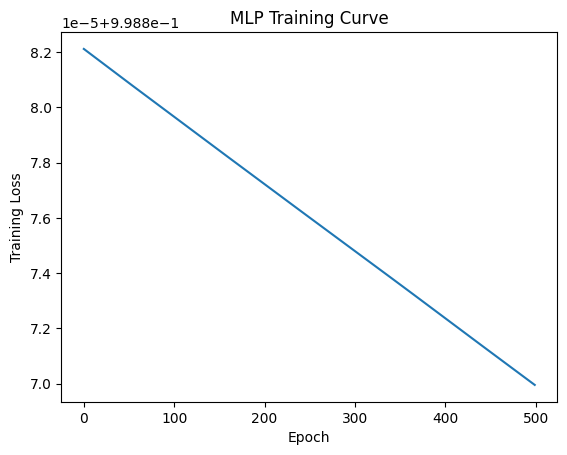

In [47]:
import matplotlib.pyplot as plt
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("MLP Training Curve")
plt.show()


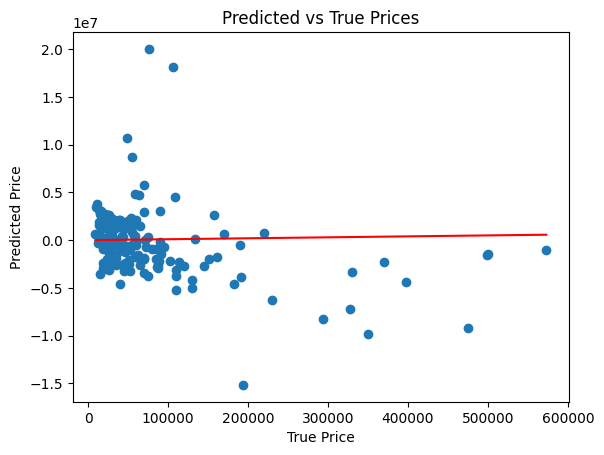

In [48]:
y_test_pred_scaled = mlp.predict(X_test_np)
y_test_pred = y_test_pred_scaled * y_std + y_mean
y_test_true = y_test.values.reshape(-1,1)


plt.scatter(y_test_true, y_test_pred)
plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs True Prices")
plt.plot([y_test_true.min(), y_test_true.max()],
         [y_test_true.min(), y_test_true.max()],
         color="red")
plt.show()

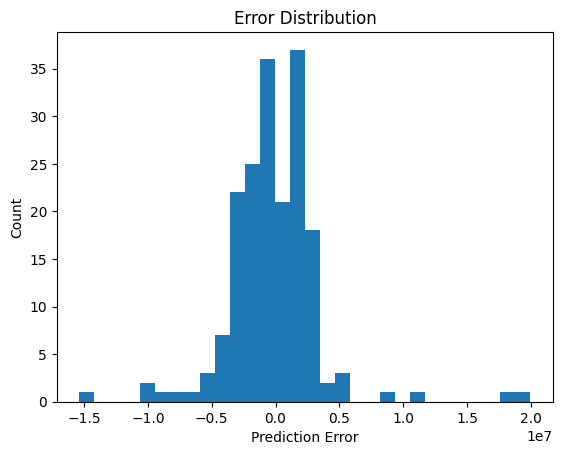

In [49]:
errors = y_test_pred - y_test_true
plt.hist(errors, bins=30)
plt.xlabel("Prediction Error")
plt.ylabel("Count")
plt.title("Error Distribution")
plt.show()


In [ ]:
import numpy as np
import pandas as pd

# -------------------------------
# 1. Preprocessing utilities
# -------------------------------

def train_val_test_split(X, y, val_ratio=0.15, test_ratio=0.15, seed=42):
    np.random.seed(seed)
    idx = np.random.permutation(len(X))
    
    test_size = int(len(X) * test_ratio)
    val_size = int(len(X) * val_ratio)
    
    test_idx = idx[:test_size]
    val_idx = idx[test_size:test_size+val_size]
    train_idx = idx[test_size+val_size:]
    
    return X.iloc[train_idx], X.iloc[val_idx], X.iloc[test_idx], \
           y.iloc[train_idx], y.iloc[val_idx], y.iloc[test_idx]


def target_encode(train_df, col, target):
    means = train_df.groupby(col)[target].mean()
    return means


def apply_target_encoding(df, col, mapping, global_mean):
    return df[col].map(mapping).fillna(global_mean)


def standardize_features(X_train, X_val, X_test):
    mean = X_train.mean()
    std = X_train.std()
    std[std == 0] = 1  # avoid division by zero
    
    X_train_std = (X_train - mean) / std
    X_val_std   = (X_val - mean) / std
    X_test_std  = (X_test - mean) / std
    
    return X_train_std, X_val_std, X_test_std


# -------------------------------
# 2. Activation functions
# -------------------------------

def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)

def leaky_relu_derivative(x, alpha=0.01):
    return np.where(x > 0, 1, alpha)


# -------------------------------
# 3. MLP Model (from scratch)
# -------------------------------

class MLPRegressor:
    def __init__(self, input_dim, hidden1=64, hidden2=32, lr=0.001):
        self.lr = lr
        
        # Xavier initialization
        self.W1 = np.random.randn(input_dim, hidden1) / np.sqrt(input_dim)
        self.b1 = np.zeros((1, hidden1))
        
        self.W2 = np.random.randn(hidden1, hidden2) / np.sqrt(hidden1)
        self.b2 = np.zeros((1, hidden2))
        
        self.W3 = np.random.randn(hidden2, 1) / np.sqrt(hidden2)
        self.b3 = np.zeros((1, 1))
    
    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = leaky_relu(self.z1)
        
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = leaky_relu(self.z2)
        
        self.z3 = self.a2 @ self.W3 + self.b3
        return self.z3  # linear output
    
    def backward(self, X, y, y_pred):
        n = len(X)
        
        dL_dz3 = (2/n) * (y_pred - y)
        
        dW3 = self.a2.T @ dL_dz3
        db3 = np.sum(dL_dz3, axis=0, keepdims=True)
        
        da2 = dL_dz3 @ self.W3.T
        dz2 = da2 * leaky_relu_derivative(self.z2)
        
        dW2 = self.a1.T @ dz2
        db2 = np.sum(dz2, axis=0, keepdims=True)
        
        da1 = dz2 @ self.W2.T
        dz1 = da1 * leaky_relu_derivative(self.z1)
        
        dW1 = X.T @ dz1
        db1 = np.sum(dz1, axis=0, keepdims=True)
        
        # Gradient descent
        self.W3 -= self.lr * dW3
        self.b3 -= self.lr * db3
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
    
    def fit(self, X, y, epochs=500):
        for epoch in range(epochs):
            y_pred = self.forward(X)
            loss = np.mean((y_pred - y)**2)
            self.backward(X, y, y_pred)
            
            if epoch % 50 == 0:
                print(f"Epoch {epoch} | Loss: {loss:.4f}")
    
    def predict(self, X):
        return self.forward(X)


# -------------------------------
# 4. Full Pipeline
# -------------------------------

# Separate target
y = df["Price"]
X = df.drop(columns=["Price"])

# Handle missing values
X = X.fillna(X.mode().iloc[0])
y = y.fillna(y.mean())

# Identify categorical columns
cat_cols = X.select_dtypes(include=["object"]).columns
num_cols = X.select_dtypes(exclude=["object"]).columns

# Split first (important for target encoding!)
X_train, X_val, X_test, y_train, y_val, y_test = train_val_test_split(X, y)

# Target encoding
global_mean = y_train.mean()
for col in cat_cols:
    mapping = target_encode(pd.concat([X_train, y_train], axis=1), col, "Price")
    X_train[col] = apply_target_encoding(X_train, col, mapping, global_mean)
    X_val[col]   = apply_target_encoding(X_val, col, mapping, global_mean)
    X_test[col]  = apply_target_encoding(X_test, col, mapping, global_mean)

# Standardize features
X_train_std, X_val_std, X_test_std = standardize_features(
    X_train, X_val, X_test
)

# Standardize target
y_mean = y_train.mean()
y_std = y_train.std()
y_train_std = (y_train - y_mean) / y_std
y_val_std   = (y_val - y_mean) / y_std
y_test_std  = (y_test - y_mean) / y_std

# Convert to numpy
X_train_np = X_train_std.values
X_val_np   = X_val_std.values
X_test_np  = X_test_std.values

y_train_np = y_train_std.values.reshape(-1,1)
y_val_np   = y_val_std.values.reshape(-1,1)
y_test_np  = y_test_std.values.reshape(-1,1)

print("Max X:", np.max(X_train_np))
print("Min X:", np.min(X_train_np))


# -------------------------------
# 5. Train Model
# -------------------------------

mlp = MLPRegressor(input_dim=X_train_np.shape[1], lr=0.001)
mlp.fit(X_train_np, y_train_np, epochs=500)


# -------------------------------
# 6. Evaluation
# -------------------------------

val_pred = mlp.predict(X_val_np)
test_pred = mlp.predict(X_test_np)

val_mse = np.mean((val_pred - y_val_np)**2)
test_mse = np.mean((test_pred - y_test_np)**2)

print("Validation MSE:", val_mse)
print("Test MSE:", test_mse)
